In [ ]:
import pandas as pd
import numpy as np
import torch
import os
import pickle 


## train test splits by perturbation type

In [2]:
combined_meta = pickle.load(open('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/combined_tensors_metadata.pkl', 'rb'))
combined_meta






{'inputs': {'waveforms_parquet_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/raw_waveforms_filtered_by_core_smoothed_despiked.parquet',
  'med_parquet_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet',
  'hosp_input_dir': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/input_data'},
 'params': {'interval_seconds': 10,
  'trajectory_duration_minutes': 20,
  'context_duration_minutes': 60,
  'context_interval_minutes': 10,
  'force_reload': False},
 'outputs': {'base_output_dir': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3',
  'med_tensors_output_dir': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/med_tensors_output',
  'physio_tensors_output_dir': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/physio_tensors_output',
  'context_tensors_output_dir': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/context_tensors_output',
  'med_metadata_path': '/n/netscratch/mzitnik_lab/Lab/rconci/B

In [ ]:
from collections import Counter, defaultdict
import numpy as np
import pandas as pd

# --- helpers
def _to_utc(s): 
    return pd.to_datetime(s, errors="coerce", utc=True)

def _norm_label(x: str) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)): 
        return ""
    return str(x).strip()

# Treat IV bolus of NaCl/LR as distinct tokens
_BOLUS_NAME = "03-IV Fluid Bolus"
_LR_ALIASES = {"LR"}
_NACL_ALIASES = {"NaCl 0.9%"}  # extend as needed

def _med_token(row: pd.Series) -> str:
    base = _norm_label(row.get("item_label"))
    iname = str(row.get("input_name", "")).strip()
    if iname == _BOLUS_NAME:
        if base in _NACL_ALIASES:
            return f"{base} [Bolus]"
        if base in _LR_ALIASES:
            return f"{base} [Bolus]"
    return base

def rank_action_window_combinations(
    df: pd.DataFrame,
    window_minutes: int = 20,
    drop_empty: bool = True,
):
    """
    For each (hadm_id, action_cluster_id):
      • t0 = earliest trigger start_time; fallback to earliest start if no trigger in cluster
      • action window = [t0, t0 + window_minutes]
      • include any med rows that overlap the window:
          start_time <= window_end  AND  (end_time is NA OR end_time >= t0)
      • build a unique, sorted tuple of med tokens for that cluster
        (NaCl/LR IV bolus gets a '[Bolus]' tag separate from drips)

    Returns:
      combo_df: DataFrame with columns ['combo','count','percent','example_pairs']
      cluster_combo_map: DataFrame mapping each (hadm_id, action_cluster_id) to its 'combo'
    """
    m = df.copy()
    # keep only clusters
    m = m[m["action_cluster_id"].notna()]
    if m.empty:
        return (
            pd.DataFrame(columns=["combo","count","percent","example_pairs"]),
            pd.DataFrame(columns=["hadm_id","action_cluster_id","combo"])
        )

    # times
    m["start_time"] = _to_utc(m["start_time"])
    m["end_time"]   = _to_utc(m.get("end_time"))

    gkeys = ["hadm_id", "action_cluster_id"]

    # t0 = earliest trigger; fallback to earliest start
    trig_mask = m["trigger"].fillna(False)
    t0_trigger  = m.loc[trig_mask].groupby(gkeys)["start_time"].min()
    t0_fallback = m.groupby(gkeys)["start_time"].min()
    t0_series   = t0_trigger.combine_first(t0_fallback)

    delta = pd.Timedelta(minutes=window_minutes)

    cluster_pairs   = []
    cluster_combos  = []
    for (hadm, cid), t0 in t0_series.items():
        sub = m[(m["hadm_id"] == hadm) & (m["action_cluster_id"] == cid)]
        if pd.isna(t0):
            continue
        window_end = t0 + delta

        # overlap with action window
        st = sub["start_time"]
        et = sub["end_time"]
        overlap = (st <= window_end) & (et.isna() | (et >= t0))
        win = sub.loc[overlap].copy()
        if win.empty and drop_empty:
            continue

        # make tokens (bolus NaCl/LR distinct)
        win["med_token"] = win.apply(_med_token, axis=1)
        meds = tuple(sorted(t for t in win["med_token"].dropna().unique() if t and t.strip()))
        if not meds and drop_empty:
            continue

        cluster_pairs.append((hadm, cid))
        cluster_combos.append(meds)

    if not cluster_combos:
        return (
            pd.DataFrame(columns=["combo","count","percent","example_pairs"]),
            pd.DataFrame(columns=["hadm_id","action_cluster_id","combo"])
        )

    # Count combos across all clusters
    counter = Counter(cluster_combos)
    total   = sum(counter.values())

    # Ranked table
    rows = []
    # collect up to a few example pairs per combo
    examples = defaultdict(list)
    for pair, combo in zip(cluster_pairs, cluster_combos):
        if len(examples[combo]) < 5:
            examples[combo].append(pair)

    for combo, cnt in counter.most_common():
        rows.append({
            "combo": combo,
            "count": cnt,
            "percent": cnt / total if total else np.nan,
            "example_pairs": examples[combo],  # list of (hadm_id, action_cluster_id)
        })
    combo_df = pd.DataFrame(rows)

    # Mapping each cluster -> its combo
    cluster_combo_map = pd.DataFrame(cluster_pairs, columns=["hadm_id","action_cluster_id"])
    cluster_combo_map["combo"] = cluster_combos

    return combo_df, cluster_combo_map

In [1]:
med_df = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet')

NameError: name 'pd' is not defined

In [ ]:
med_df

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,...,rate/weight_capped,rate/weight_norm,item_label,rate_norm,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank
0,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,6.602113,mL/hour,64.0,...,0.103158,0.055155,NaCl 0.9%,0.055155,0.099358,False,,53,2,<NA>
1,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,0.110035,mcg/kg/min,64.0,...,0.110035,0.257163,Norepinephrine,0.257163,0.231630,False,,53,2,<NA>
2,65411,100098,225158,02-Fluids (Crystalloids),Continuous IV,2108-04-11 10:02:00+00:00,2108-04-12 21:44:00+00:00,5.000000,mL/hour,64.0,...,0.078125,0.041771,NaCl 0.9%,0.041771,0.055155,False,,59,1,<NA>
3,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,8.403035,mL/hour,64.0,...,0.131297,0.070200,NaCl 0.9%,0.070200,0.041771,True,uptitrate_gt25pct_abs>=0.02,53,2,1
4,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,0.140051,mcg/kg/min,64.0,...,0.140051,0.327312,Norepinephrine,0.327312,0.257163,True,uptitrate_gt25pct_abs>=0.02,53,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35534,84020,199751,221749,01-Drips,Continuous Med,2132-01-23 06:01:00+00:00,2132-01-23 07:00:00+00:00,0.756308,mcg/kg/min,83.1,...,0.756308,0.179936,Phenylephrine,0.179936,0.239897,False,,14,1,<NA>
35535,84020,199751,221289,01-Drips,Continuous Med,2132-01-23 06:03:00+00:00,2132-01-23 07:58:00+00:00,0.010003,mcg/kg/min,83.1,...,0.010003,0.052053,Epinephrine,0.052053,0.104107,False,,14,1,<NA>
35536,84020,199751,225158,01-Drips,Continuous Med,2132-01-23 06:58:00+00:00,2132-01-23 07:42:00+00:00,0.998818,mL/hour,83.1,...,0.012019,0.006426,NaCl 0.9%,0.006426,0.101093,False,,14,1,<NA>
35537,84020,199751,225158,01-Drips,Continuous Med,2132-01-23 07:00:00+00:00,2132-01-23 07:38:00+00:00,10.455171,mL/hour,83.1,...,0.125814,0.067269,NaCl 0.9%,0.067269,0.006426,True,uptitrate_gt25pct_abs>=0.02,14,1,1


In [ ]:
combo_df, cluster_combo_map = rank_action_window_combinations(med_df)

In [ ]:
cluster_combo_map

,hadm_id,action_cluster_id,combo
0,100098,53,"(NaCl 0.9%, Norepinephrine)"
1,100098,55,"(Albumin 25%, NaCl 0.9%, Norepinephrine)"
2,100098,56,"(NaCl 0.9%, NaCl 0.9% [Bolus], Norepinephrine)"
3,100098,58,"(NaCl 0.9%, Norepinephrine)"
4,100098,59,"(Albumin 25%, NaCl 0.9%)"
...,...,...,...
8744,199751,10,"(Epinephrine,)"
8745,199751,11,"(NaCl 0.9%, Phenylephrine)"
8746,199751,12,"(Albumin 5%, NaCl 0.9%)"
8747,199751,13,"(Epinephrine,)"


In [ ]:
combo_df

,combo,count,percent,example_pairs
0,"(NaCl 0.9%, Phenylephrine)",1486,0.169848,"[(100098, 79), (100098, 80), (100098, 82), (10..."
1,"(NaCl 0.9%, Norepinephrine)",1430,0.163447,"[(100098, 53), (100098, 58), (100098, 60), (10..."
2,"(NaCl 0.9%,)",1351,0.154418,"[(100098, 118), (100098, 144), (100477, 8), (1..."
3,"(NaCl 0.9% [Bolus],)",804,0.091896,"[(100098, 61), (100098, 68), (100098, 69), (10..."
4,"(NaCl 0.9%, NaCl 0.9% [Bolus])",356,0.040690,"[(100477, 9), (100477, 10), (100477, 12), (101..."
...,...,...,...,...
211,"(Albumin 25%, LR [Bolus], NaCl 0.9%)",1,0.000114,"[(197999, 14)]"
212,"(NaCl 0.9%, Packed Red Blood Cells, Phenylephr...",1,0.000114,"[(198022, 13)]"
213,"(Albumin 5%, Milrinone, NaCl 0.9%, Vasopressin)",1,0.000114,"[(198022, 17)]"
214,"(Epinephrine, Milrinone, NaCl 0.9%, Norepineph...",1,0.000114,"[(198022, 19)]"


## train test splits by hadm_id

In [3]:
baseline_tensor_sample = torch.load('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/baseline_tensors_output/baseline_tensors/baseline_100098.pt', weights_only=False)

In [5]:
baseline_tensor_sample.shape

torch.Size([15])

In [30]:
import pickle
baseline_metadata = pickle.load(open('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/baseline_tensors_output/baseline_tensors/baseline_metadata.pkl', 'rb'))
baseline_metadata


{'feature_names': ['AGE',
  'ADMIT_DURATION',
  'GENDER_M',
  'MARITAL_STATUS_MARRIED',
  'MARITAL_STATUS_SEPARATED',
  'MARITAL_STATUS_SINGLE',
  'MARITAL_STATUS_UNKNOWN (DEFAULT)',
  'MARITAL_STATUS_WIDOWED',
  'INSURANCE_Medicaid',
  'INSURANCE_Medicare',
  'INSURANCE_Private',
  'INSURANCE_Self Pay',
  'ADMISSION_LOCATION_PHYS REFERRAL/NORMAL DELI',
  'ADMISSION_LOCATION_TRANSFER FROM HOSP/EXTRAM',
  'ADMISSION_TYPE_EMERGENCY'],
 'feature_dim': 15}

In [32]:
import os
import torch
import pandas as pd

baseline_tensors_dir = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/baseline_tensors_output/baseline_tensors'
files = sorted([f for f in os.listdir(baseline_tensors_dir) if f.endswith('.pt')])

ok, bad, loaded = [], [], []

for f in files:
    path = os.path.join(baseline_tensors_dir, f)
    try:
        obj = torch.load(path, map_location='cpu', weights_only=False)
        loaded.append(obj)
        ok.append(f)
    except Exception as e:
        bad.append((f, str(e)))

print(f"Total: {len(files)} | Loaded: {len(ok)} | Failed: {len(bad)}")
if bad:
    print("First few failures:")
    for name, err in bad[:5]:
        print(f"  {name} -> {err}")

# Build DataFrame only from the successful loads
if len(loaded) > 0:
    # If objects are dict-like
    if isinstance(loaded[0], dict):
        baseline_df = pd.DataFrame.from_records(loaded)
    # If they are tensors
    elif torch.is_tensor(loaded[0]):
        baseline_df = pd.DataFrame([t.cpu().numpy().ravel() for t in loaded])
    else:
        baseline_df = pd.DataFrame(loaded)

    print("DataFrame shape:", baseline_df.shape)
else:
    baseline_df = pd.DataFrame()
    print("No valid tensors loaded -> empty DataFrame")

Total: 201 | Loaded: 201 | Failed: 0
DataFrame shape: (201, 15)


In [33]:
baseline_df.columns = baseline_metadata['feature_names']

In [34]:
baseline_df

,AGE,ADMIT_DURATION,GENDER_M,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SEPARATED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_UNKNOWN (DEFAULT),MARITAL_STATUS_WIDOWED,INSURANCE_Medicaid,INSURANCE_Medicare,INSURANCE_Private,INSURANCE_Self Pay,ADMISSION_LOCATION_PHYS REFERRAL/NORMAL DELI,ADMISSION_LOCATION_TRANSFER FROM HOSP/EXTRAM,ADMISSION_TYPE_EMERGENCY
0,0.343951,0.818715,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.124678,-0.848122,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.221046,-0.565971,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.417043,0.258918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,-0.167687,-0.800768,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1.410239,0.183201,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
197,0.563225,-0.608175,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
198,0.563225,-0.602220,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
199,1.440320,-0.754380,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [35]:
from sklearn.cluster import DBSCAN

X_umap = umap.UMAP(n_components=5, random_state=42).fit_transform(baseline_df)

clustering = DBSCAN(eps=0.7, min_samples=5).fit(X_umap)

print(clustering.labels_)  # cluster IDs for each sample

/n/holylfs06/LABS/mzitnik_lab/Lab/rconci/micromamba/envs/cf_icu2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[3 0 0 1 2 3 1 3 0 1 0 0 1 1 0 3 2 1 1 1 0 1 0 0 1 2 2 0 3 1 3 0 0 1 0 1 0
 0 1 0 1 1 0 0 0 0 1 2 1 0 2 1 2 1 1 0 3 0 0 0 1 0 2 0 0 1 0 1 2 0 1 2 1 2
 0 1 0 0 1 0 1 0 0 0 0 0 1 3 1 2 1 0 1 2 1 1 3 0 0 2 2 1 1 1 2 1 0 0 2 0 3
 0 0 3 0 2 1 1 1 1 3 0 0 2 0 2 0 1 3 2 0 1 1 3 1 0 0 0 1 1 1 0 1 1 2 2 0 2
 1 0 0 1 2 1 3 1 2 2 1 0 2 0 0 3 1 1 0 0 1 1 0 2 0 1 2 2 0 0 0 1 2 1 1 0 3
 1 1 1 3 1 2 0 0 0 1 0 1 0 0 0 0]


In [36]:
baseline_df['cluster'] = clustering.labels_
baseline_df.head()


,AGE,ADMIT_DURATION,GENDER_M,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SEPARATED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_UNKNOWN (DEFAULT),MARITAL_STATUS_WIDOWED,INSURANCE_Medicaid,INSURANCE_Medicare,INSURANCE_Private,INSURANCE_Self Pay,ADMISSION_LOCATION_PHYS REFERRAL/NORMAL DELI,ADMISSION_LOCATION_TRANSFER FROM HOSP/EXTRAM,ADMISSION_TYPE_EMERGENCY,cluster
0,0.343951,0.818715,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,3
1,0.124678,-0.848122,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,1.221046,-0.565971,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
3,0.417043,0.258918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
4,-0.167687,-0.800768,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,2


In [37]:
cluster_summary = baseline_df.groupby('cluster').mean()   # average feature values
cluster_counts = baseline_df['cluster'].value_counts()    # cluster sizes

In [38]:
cluster_summary

,AGE,ADMIT_DURATION,GENDER_M,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SEPARATED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_UNKNOWN (DEFAULT),MARITAL_STATUS_WIDOWED,INSURANCE_Medicaid,INSURANCE_Medicare,INSURANCE_Private,INSURANCE_Self Pay,ADMISSION_LOCATION_PHYS REFERRAL/NORMAL DELI,ADMISSION_LOCATION_TRANSFER FROM HOSP/EXTRAM,ADMISSION_TYPE_EMERGENCY
cluster,,,,,,,,,,,,,,,
0,0.637242,-0.415606,0.594937,0.721519,0.012658,0.063291,0.000000,0.126582,0.012658,0.987342,0.000000,0.000000,0.594937,0.126582,0.493671
1,-0.835803,0.306112,0.676056,0.464789,0.000000,0.323944,0.000000,0.056338,0.183099,0.169014,0.535211,0.014085,0.042254,0.295775,0.985915
2,0.567655,-0.470016,0.393939,0.000000,0.000000,0.151515,0.030303,0.484848,0.000000,1.000000,0.000000,0.000000,0.000000,0.363636,1.000000
3,-0.309809,-0.437244,0.722222,0.833333,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.111111


In [22]:
cluster_counts

cluster
0    79
1    71
2    33
3    18
Name: count, dtype: int64

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(baseline_df.drop(columns='cluster'), baseline_df['cluster'])
importances = pd.Series(rf.feature_importances_, index=baseline_df.columns[:-1])
print(importances.sort_values(ascending=False).head(10))

INSURANCE_Medicare                              0.171151
AGE                                             0.167061
ADMISSION_LOCATION_PHYS REFERRAL/NORMAL DELI    0.148546
MARITAL_STATUS_MARRIED                          0.123797
ADMIT_DURATION                                  0.110386
INSURANCE_Private                               0.093136
ADMISSION_TYPE_EMERGENCY                        0.090448
MARITAL_STATUS_WIDOWED                          0.030636
MARITAL_STATUS_SINGLE                           0.021403
GENDER_M                                        0.015230
dtype: float64


<Axes: xlabel='cluster', ylabel='AGE'>

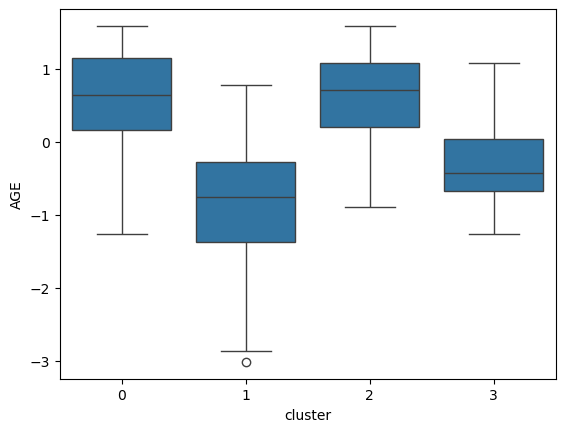

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=baseline_df, x='cluster', y='AGE')

In [8]:
import sys, os
import torch

# Allow imports from project modules
sys.path.append('/n/holylfs06/LABS/mzitnik_lab/Lab/rconci/Counterfactual_ICU/src_new/models')
from dataloaders.MIMIC_data import MIMICDataModule


data_root = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data'
icu_stays = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/input_data/ICUSTAYS.csv'

# Build DataModule and fetch one training batch
dm = MIMICDataModule(
    data_root=data_root,
    icu_stays_path=icu_stays,
    batch_size=2,
    num_workers=0,
    random_state=42,
    max_samples=14,
    use_raindrop_context=True,
)
dm.setup('fit')
loader = dm.train_dataloader()


[DEBUG] Limited to 14 samples for testing
Split 'train': 14 trajectories
Target trajectory split: 3440/737/738
Actual trajectory split: 3454/730/731
Trajectory percentages: 70.3%/14.9%/14.9%
Computing normalization stats and loading normalized tensors for 4931 files...
Normalization stats computed: {0: 10.0, 1: 5.069218635559082, 2: 6.323300838470459}


Loading normalized med tensors: 100%|██████████| 4931/4931 [00:03<00:00, 1359.02it/s]


Loaded 4931 normalized med tensors into memory!
[DEBUG] Limited to 14 samples for testing
Split 'val': 14 trajectories
Target trajectory split: 3440/737/738
Actual trajectory split: 3454/730/731
Trajectory percentages: 70.3%/14.9%/14.9%
Computing normalization stats and loading normalized tensors for 4931 files...
Normalization stats computed: {0: 10.0, 1: 5.069218635559082, 2: 6.323300838470459}


Loading normalized med tensors: 100%|██████████| 4931/4931 [00:03<00:00, 1390.16it/s]


Loaded 4931 normalized med tensors into memory!


In [10]:
(rd_src, rd_times, rd_length, static_feats, ic_tensor, ic_mask_tensor, p_out_values, p_out_mask, t_Y, med_traj_values, med_traj_mask, med_traj_time_sec, med_tensors, hadm_id, traj_id) = next(iter(loader))

print('Batch shapes:')
print('  rd_src:', rd_src.shape, 'rd_times:', rd_times.shape, 'rd_length:', rd_length.shape)
print('  static:', static_feats.shape)


Batch shapes:
  rd_src: torch.Size([2, 6, 52]) rd_times: torch.Size([2, 6]) rd_length: torch.Size([2])
  static: torch.Size([2, 15])


In [16]:
hadm_id

tensor([100098, 100098])

In [34]:
med_context_normalised = med_tensors[0]
med_context_normalised

tensor([[0.0000, 0.0000, 0.2749,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2749,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2749,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.2749,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2749,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.2749,  ..., 0.0000, 0.0000, 0.0000]])

In [35]:
med_context_normalised = med_tensors[0]
num_features = 5
num_meds = med_context_normalised.shape[1] // num_features
med_context_normalised[0,:].view(num_meds, num_features)


tensor([[0.0000, 0.0000, 0.2749, 0.0078, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1214, 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0134, 0.3786, 0.3193, 1.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0060, 0.1066, 0.2343, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],


In [18]:
med_tensor_sample = torch.load('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output/med_tensor_100098_61.pt', weights_only=False)

In [30]:
num_features = 5
med_context_sample = med_tensor_sample[-1]
num_meds = med_context_sample.shape[1] // num_features
med_context_sample[0,:].view(num_meds, num_features)

tensor([[0.0000, 0.0000, 1.7383, 0.0078, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6152, 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1344, 1.9194, 2.0188, 1.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.5404, 1.4817, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],


In [ ]:
med_tensor_dir_path = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output'
med_tensors = os.listdir(med_tensor_dir_path)

feature_names: List[str] = [
        "rate_hr_weight_norm",
        "pre_on_hours_log1p",
        "cumulative_since_start_hours_log1p",
        "post_stop_effect",
        "trigger_flag",
    ]


cols_idx_to_normalise = [0, 1, 2]

max_values = {}

for med_tensor in med_tensors:
    med_tensor_path = os.path.join(med_tensor_dir_path, med_tensor)
    med_tensor_data = torch.load(med_tensor_path, weights_only=False)
    med_context = med_tensor_data[-1]
    for col_idx in cols_idx_to_normalise:
        med_context_col = med_context[:, col_idx]
        max_val = np.max(med_context_col)
        if col_idx not in max_values:
            max_values[col_idx] = max_val
        else:
            max_values[col_idx] = max(max_values[col_idx], max_val)

#normalise
for col_idx in cols_idx_to_normalise:
    med_context[:, col_idx] = med_context[:, col_idx] / max_values[col_idx]




    
